# 04 distance matrices and ordinations
Bur oak common garden genomics  
ahipp@mortonarb.org, 2024-09-24  

## Running this notebook
see `01.dataProcessingBash` for details. Make sure you run this notebook in the `garden` conda environment. As a reminder, here's the folder structure:

In [1]:
system2("tree", args = c('../', '-d'), stdout = T) |> print()

 [1] "../"                                    
 [2] "├── condaEnv"                           
 [3] "├── data"                               
 [4] "│   ├── bed"                            
 [5] "│   ├── KHUFU"                          
 [6] "│   └── little-maps"                    
 [7] "│       ├── originals"                  
 [8] "│       │   ├── alba_litt802av"         
 [9] "│       │   ├── bicolor_litt804av"      
[10] "│       │   ├── macrocarpa_litt823av"   
[11] "│       │   ├── muehlenbergii_litt826av"
[12] "│       │   └── stellata_litt835av"     
[13] "│       └── shapefiles"                 
[14] "├── out"                                
[15] "│   ├── admixture"                      
[16] "│   │   ├── imputed"                    
[17] "│   │   ├── imputed.m90"                
[18] "│   │   ├── raw"                        
[19] "│   │   └── raw.m90"                    
[20] "│   ├── admixture.plots"                
[21] "│   │   ├── imputed"                    
[22] "│   │  

## loading genetic distances, converting
The genetic distance matrices from RAxML (long format), converting to a symmetrical distance matrix that we can subset for analysis. I'm using a function I wrote for an earlier paper but haven't put anywhere (Whittemore et al. 2021, _Ulmus_ phylogeny, _Systematic Botany_).

In [2]:
## convert raxml-style long-format pairwise distance table into a square distance matrix

rax.conv <- function(file, diag.fill = 0, verbose = FALSE) {
  dat <- read.table(file, as.is = T)
  allTips <- sort(unique(unlist(dat[1:2])))
  if(verbose) message(paste('making a matrix of dim =', length(allTips)))
  out <- matrix(NA, length(allTips), length(allTips),
                dimnames = list(allTips, allTips))
  for(i in 1:dim(dat)[1]) {
      # if(verbose) {if(i / 10000 == i %/% 10000) message(paste('doing line', i, 'of', dim(dat)[1]))}
      out[dat[i, 'V1'], dat[i, 'V2']] <-
          out[dat[i, 'V2'], dat[i, 'V1']] <-
          dat[i, 'V3']
      } # close i
  diag(out) <- diag.fill
  out
  } # close rax.conv

# and either read or convert our data:

if('dists.done.Rdata' %in% dir('../out')) {
    load('../out/dists.done.Rdata')
    message("*** Distances read from file; if you want to recalc these, delete `../out/dists.done.Rdata` and rerun cell **")
  } else {
        dat.dist <- list(
            imputed = rax.conv('../out/RAxML_distances.KHU075_imputed.bp5000', verbose = T),
            raw.m90 = rax.conv('../out/RAxML_distances.KHU075_raw.m90.bp5000', verbose = T),
            imputed.m90 = rax.conv('../out/RAxML_distances.KHU075_imputed.m90.bp5000', verbose = T)
            ) # close list
        save(dat.dist, file = '../out/dists.done.Rdata')
    }

*** Distances read from file; if you want to recalc these, delete `../out/dists.done.Rdata` and rerun cell **



Then check 'em:

In [3]:
message('unchanged dimnames')
lapply(dat.dist, function(x) row.names(x) |> head())

for(i in names(dat.dist)) {
    dimnames(dat.dist[[i]])[[1]] <- dimnames(dat.dist[[i]])[[2]] <-
    strsplit(dimnames(dat.dist[[i]])[[1]], '_', fixed = T) |> sapply(FUN = '[', 1)
    }

# and recheck them:
message('cleaned dimnames')
lapply(dat.dist, function(x) row.names(x) |> head())

unchanged dimnames



$imputed
[1] "MOR0001_MOR0001" "MOR0004_MOR0004" "MOR0005_MOR0005" "MOR0006_MOR0006"
[5] "MOR0007_MOR0007" "MOR0008_MOR0008"

$raw.m90
[1] "MOR0001_MOR0001" "MOR0004_MOR0004" "MOR0005_MOR0005" "MOR0006_MOR0006"
[5] "MOR0007_MOR0007" "MOR0008_MOR0008"

$imputed.m90
[1] "MOR0001_MOR0001" "MOR0004_MOR0004" "MOR0005_MOR0005" "MOR0006_MOR0006"
[5] "MOR0007_MOR0007" "MOR0008_MOR0008"

cleaned dimnames



$imputed
[1] "MOR0001" "MOR0004" "MOR0005" "MOR0006" "MOR0007" "MOR0008"

$raw.m90
[1] "MOR0001" "MOR0004" "MOR0005" "MOR0006" "MOR0007" "MOR0008"

$imputed.m90
[1] "MOR0001" "MOR0004" "MOR0005" "MOR0006" "MOR0007" "MOR0008"

## Subset _Q. macrocarpa_ acorn data
Create subsets of individuals that we can use to subset the distance matrices:
1. individuals with >10% called SNPs, all states;
2. the above, subsetted just to garden; and
3. the above dataset, subsetted by state

In [4]:
dat.meta <- read.csv('../out/oak.metadata.cleaned.csv', row.names = 1)
dat.raw.stats <- read.csv('../out/vcf.stats.raw.table.csv', row.names = 1)

# 1
subset.qmac <- list(m10 = intersect(row.names(dat.meta)[grep('macrocarpa', dat.meta$Qsp)], 
                                    row.names(dat.raw.stats)[dat.raw.stats$percentPass > 0.10]
                                    )
                    )

#2
subset.qmac$garden = intersect(subset.qmac$m10, 
                               row.names(dat.meta)[!is.na(dat.meta$MOTHER)]
                               )

# 3
subset.qmac$IL <- row.names(dat.meta[subset.qmac$garden, ])[dat.meta[subset.qmac$garden, 'stateAbb'] == 'IL']
subset.qmac$MN <- row.names(dat.meta[subset.qmac$garden, ])[dat.meta[subset.qmac$garden, 'stateAbb'] == 'MN']
subset.qmac$OK <- row.names(dat.meta[subset.qmac$garden, ])[dat.meta[subset.qmac$garden, 'stateAbb'] == 'OK']

# check
sapply(subset.qmac, length)

m10 garden     IL     MN     OK 
   755    718    288    287    143

## do ordinations

In [5]:
library(vegan)
library(ggplot2)

Loading required package: permute

Loading required package: lattice

This is vegan 2.6-8



### do the ordinations, just k = 2 for now
... use this example for connecting mothers: https://stackoverflow.com/questions/47516448/how-to-get-ordispider-like-clusters-in-ggplot-with-nmds

In [6]:
int <- list(m = intersect(subset.qmac$m10, colnames(dat.dist$raw.m90)), # why are some individuals missing?
            g = intersect(subset.qmac$garden, colnames(dat.dist$raw.m90)),
            IL = intersect(subset.qmac$IL, colnames(dat.dist$raw.m90)), 
            MN = intersect(subset.qmac$MN, colnames(dat.dist$raw.m90)),
            OK = intersect(subset.qmac$OK, colnames(dat.dist$raw.m90))
            )
sapply(int, length)
mds <- list(macrocarpa = monoMDS(dat.dist$raw.m90[int$m, int$m]),
            garden = monoMDS(dat.dist$raw.m90[int$g, int$g]),
            IL = monoMDS(dat.dist$raw.m90[int$IL, int$IL]),
            MN = monoMDS(dat.dist$raw.m90[int$MN, int$MN]),
            OK = monoMDS(dat.dist$raw.m90[int$OK, int$OK])
            )

m   g  IL  MN  OK 
755 718 288 287 143

$macrocarpa
NULL

$garden
NULL

$IL
NULL

$MN
NULL

$OK
NULL

ERROR: Error in cols25(): could not find function "cols25"


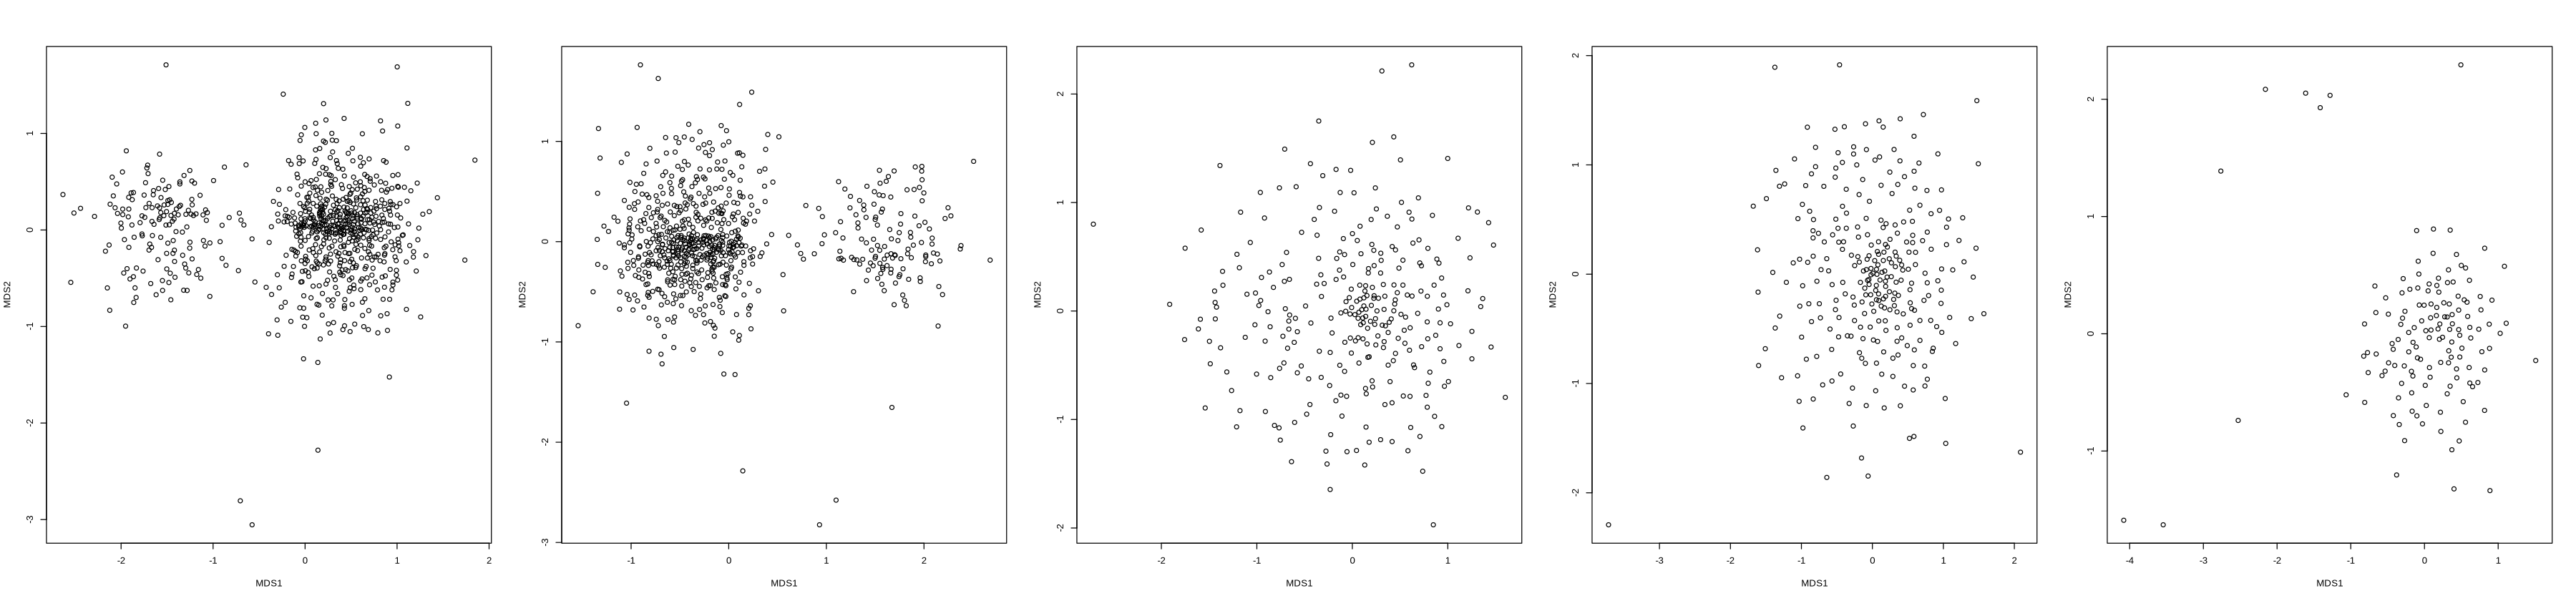

In [7]:
options(repr.plot.width=30)
layout(matrix(1:5, 1))
sapply(mds, function(x) plot(x$points))
       
scrs <- scores(mds$garden)
scrs <- data.frame(scrs, 
                   mother = dat.meta[row.names(scrs), 'MOTHER'], 
                   state = dat.meta[row.names(scrs), 'stateAbb'])
# cent <- aggregate(cbind(MDS1, MDS2) ~ mother, data = scrs, FUN = mean)    
# segs <- merge(scrs, setNames(cent, c('mother','oMDS1','oMDS2')),
#                   by = 'mother', sort = FALSE)

ggplot(scrs, aes(x = MDS1, y = MDS2, colour = state)) +
    # geom_segment(data = segs,
    #             mapping = aes(xend = oMDS1, yend = oMDS2), 
    #             linewidth = 0.2) +
    # geom_point(data = cent, size = 3) + 
    geom_point(data = scrs, size = 3) + 
    scale_colour_manual(values = cols25())
    
ggsave(paste0('../out/mds.gardenAllStates.pdf'), width = 16, height = 9, units = 'in')



In [ ]:
plot(mds$MN)

## Plot by mothers
We'll start with Illinois, as that one seems pretty straightforward. I'm using this as an example: https://stackoverflow.com/questions/47516448/how-to-get-ordispider-like-clusters-in-ggplot-with-nmds

In [ ]:
options(repr.plot.width=30, repr.plot.height = 20)

library(ggplot2)
library(pals)

for(stateCode in c('IL', 'MN', 'OK')) {
    # make mother site translation table
    message(paste('doing population', stateCode))
    site_mat <- dat.meta[grep(paste0('_', stateCode), dat.meta$Qsp, fixed = T), c('motherSite', 'Site_georef')] 
    site_mat$motherSite <- sapply(strsplit(site_mat$motherSite, '_', fixed = T), '[', 2)
    site_mat <- site_mat[!duplicated(site_mat$motherSite), ]
    if(any(is.na(site_mat$Site_georef))) 
        site_mat$Site_georef[is.na(site_mat$Site_georef)] <- site_mat$motherSite[is.na(site_mat$Site_georef)]
    site_trans <- site_mat$Site_georef
    names(site_trans) <- site_mat$motherSite
    
    ### STILL NEED TO WORK IN MOTHER SITE TRANSLATION
    
    scrs <- scores(mds[[stateCode]])
    scrs <- data.frame(scrs, 
                       mother = dat.meta[row.names(scrs), 'MOTHER'], 
                       Collecting_site = site_trans[sapply(strsplit(dat.meta[row.names(scrs), 'MOTHER'], "_", fixed = T), '[', 2)]
                       )
    cent <- aggregate(cbind(MDS1, MDS2) ~ mother, data = scrs, FUN = mean)
    cent$Collecting_site <- site_trans[sapply(strsplit(cent$mother, "_", fixed = T), '[', 2)]
    
    segs <- merge(scrs, setNames(cent, c('mother','oMDS1','oMDS2')),
                  by = 'mother', sort = FALSE)
    segs$Collecting_site <- site_trans[sapply(strsplit(segs$mother, "_", fixed = T), '[', 2)]
    
    ggplot(scrs, aes(x = MDS1, y = MDS2, colour = Collecting_site)) +
      geom_segment(data = segs,
                   mapping = aes(xend = oMDS1, yend = oMDS2), 
                   linewidth = 0.2) +
      geom_point(data = cent, size = 3) + 
      geom_point() + 
    #   coord_fixed() +
      scale_colour_manual(values = cols25())
    
    ggsave(paste0('../out/mds.garden.', stateCode, '.pdf'), width = 16, height = 9, units = 'in')
    } # close stateCode


In [ ]:
site_mat <- dat.meta[grep('_IL', dat.meta$Qsp, fixed = T), c('motherSite', 'Site_georef')] 
site_mat$motherSite <- sapply(strsplit(site_mat$motherSite, '_', fixed = T), '[', 2)
site_mat <- site_mat[!duplicated(site_mat$motherSite), ]
site_trans <- site_mat$Site_georef
names(site_trans) <- site_mat$motherSite

site_trans